In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("lab04.ipynb")

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Latex

plt.style.use('fivethirtyeight') # Use plt.style.available to see more styles
sns.set()
sns.set_context("talk")
%matplotlib inline

## 加载World Bank数据到DataFramewb

In [3]:
wb = pd.read_csv('data/world_bank_misc.csv', index_col=0)
wb.head()

,Primary completion rate: Male: % of relevant age group: 2015,Primary completion rate: Female: % of relevant age group: 2015,Lower secondary completion rate: Male: % of relevant age group: 2015,Lower secondary completion rate: Female: % of relevant age group: 2015,Youth literacy rate: Male: % of ages 15-24: 2005-14,Youth literacy rate: Female: % of ages 15-24: 2005-14,Adult literacy rate: Male: % ages 15 and older: 2005-14,Adult literacy rate: Female: % ages 15 and older: 2005-14,Students at lowest proficiency on PISA: Mathematics: % of 15 year-olds: 2015,Students at lowest proficiency on PISA: Reading: % of 15 year-olds: 2015,...,Access to improved sanitation facilities: % of population: 1990,Access to improved sanitation facilities: % of population: 2015,Child immunization rate: Measles: % of children ages 12-23 months: 2015,Child immunization rate: DTP3: % of children ages 12-23 months: 2015,Children with acute respiratory infection taken to health provider: % of children under age 5 with ARI: 2009-2016,Children with diarrhea who received oral rehydration and continuous feeding: % of children under age 5 with diarrhea: 2009-2016,Children sleeping under treated bed nets: % of children under age 5: 2009-2016,Children with fever receiving antimalarial drugs: % of children under age 5 with fever: 2009-2016,Tuberculosis: Treatment success rate: % of new cases: 2014,Tuberculosis: Cases detection rate: % of new estimated cases: 2015
Afghanistan,NaN,NaN,NaN,NaN,62.0,32.0,45.0,18.0,NaN,NaN,...,21.0,32.0,68.0,78.0,62.0,41.0,4.6,11.8,87.0,58.0
Albania,108.0,105.0,97.0,97.0,99.0,99.0,98.0,96.0,26.0,7.0,...,78.0,93.0,98.0,98.0,70.0,63.0,NaN,NaN,88.0,76.0
Algeria,106.0,105.0,68.0,85.0,96.0,92.0,83.0,68.0,51.0,11.0,...,80.0,88.0,95.0,95.0,66.0,42.0,NaN,NaN,88.0,80.0
American Samoa,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,61.0,63.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,87.0
Andorra,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,100.0,100.0,96.0,97.0,NaN,NaN,NaN,NaN,83.0,87.0


In [4]:
# 查看列
display(Markdown('\n'.join(fr'{i + 1}. {c}'.replace('$', r'\$') for i, c in enumerate(wb.columns))))

1. Primary completion rate: Male: % of relevant age group: 2015
2. Primary completion rate: Female: % of relevant age group: 2015
3. Lower secondary completion rate: Male: % of relevant age group: 2015
4. Lower secondary completion rate: Female: % of relevant age group: 2015
5. Youth literacy rate: Male: % of ages 15-24: 2005-14
6. Youth literacy rate: Female: % of ages 15-24: 2005-14
7. Adult literacy rate: Male: % ages 15 and older: 2005-14
8. Adult literacy rate: Female: % ages 15 and older: 2005-14
9. Students at lowest proficiency on PISA: Mathematics: % of 15 year-olds: 2015
10. Students at lowest proficiency on PISA: Reading: % of 15 year-olds: 2015
11. Students at lowest proficiency on PISA: Science: % of 15 year-olds: 2015
12. Population: millions: 2016
13. Surface area: sq. km thousands: 2016
14. Population density: people per sq. km: 2016
15. Gross national income, Atlas method: \$ billions: 2016
16. Gross national income per capita, Atlas method: \$: 2016
17. Purchasing power parity gross national income: \$ billions: 2016
18. per capita: \$: 2016
19. Gross domestic product: % growth : 2016
20. per capita: % growth: 2016
21. Prevalence of smoking: Male: % of adults: 2015
22. Prevalence of smoking: Female: % of adults: 2015
23. Incidence of tuberculosis: per 100,000 people: 2015
24. Prevalence of diabetes: % of population ages 20 to 79: 2015
25. Incidence of HIV: Total: % of uninfected population ages 15-49: 2015
26. Prevalence of HIV: Total: % of population ages 15-49: 2015
27. Prevalence of HIV: Women's share of population ages 15+ living with HIV: %: 2015
28. Prevalence of HIV: Youth, Male: % of population ages 15-24: 2015
29. Prevalence of HIV: Youth, Female: % of population ages 15-24: 2015
30. Antiretroviral therapy coverage: % of people living with HIV: 2015
31. Cause of death: Communicable diseases and maternal, prenatal, and nutrition conditions: % of population: 2015
32. Cause of death: Non-communicable diseases: % of population: 2015
33. Cause of death: Injuries: % of population: 2015
34. Access to an improved water source: % of population: 1990
35. Access to an improved water source: % of population: 2015
36. Access to improved sanitation facilities: % of population: 1990
37. Access to improved sanitation facilities: % of population: 2015
38. Child immunization rate: Measles: % of children ages 12-23 months: 2015
39. Child immunization rate: DTP3: % of children ages 12-23 months: 2015
40. Children with acute respiratory infection taken to health provider: % of children under age 5 with ARI: 2009-2016
41. Children with diarrhea who received oral rehydration and continuous feeding: % of children under age 5 with diarrhea: 2009-2016
42. Children sleeping under treated bed nets: % of children under age 5: 2009-2016
43. Children with fever receiving antimalarial drugs: % of children under age 5 with fever: 2009-2016
44. Tuberculosis: Treatment success rate: % of new cases: 2014
45. Tuberculosis: Cases detection rate: % of new estimated cases: 2015

## Scaling
### 研究成人识字率和人均国民总收入的综合值分布
对于这两列中的空值null，本lab选择直接删除

In [5]:
# Run this next line to create a DataFrame with the appropriate index; no further action is needed.
df = pd.DataFrame(index=wb.index)

# Run this next line to create copies of the Series we want; no further action is needed.
# The "\" syntax lets us continue to write on the next line.
df['lit'] = wb['Adult literacy rate: Female: % ages 15 and older: 2005-14'] \
            + wb["Adult literacy rate: Male: % ages 15 and older: 2005-14"]
df['inc'] = wb['Gross national income per capita, Atlas method: $: 2016']

# Run this next line to drop all records that have a NaN value in either column; no further action is needed.
df.dropna(inplace=True)
print("Original records:", len(wb))
print("Final records:", len(df))

Original records: 216
Final records: 147


In [6]:
df.head(5)

,lit,inc
Afghanistan,63.0,580.0
Albania,194.0,4250.0
Algeria,151.0,4270.0
Angola,142.0,3440.0
Antigua and Barbuda,197.0,13400.0


### Q1a 使用`sns.countplot`从分类数据中创建条形图，了解识字率和人均收入的分布情况

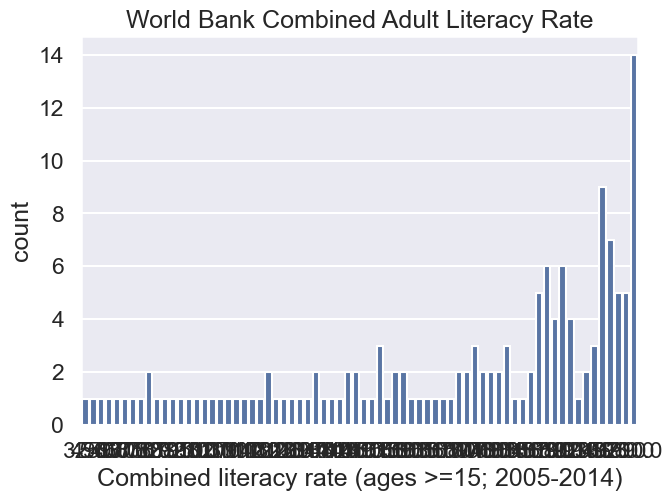

In [7]:
sns.countplot(data=df, x="lit")
plt.xlabel("Combined literacy rate (ages >=15; 2005-2014)")
plt.title('World Bank Combined Adult Literacy Rate')
plt.show()

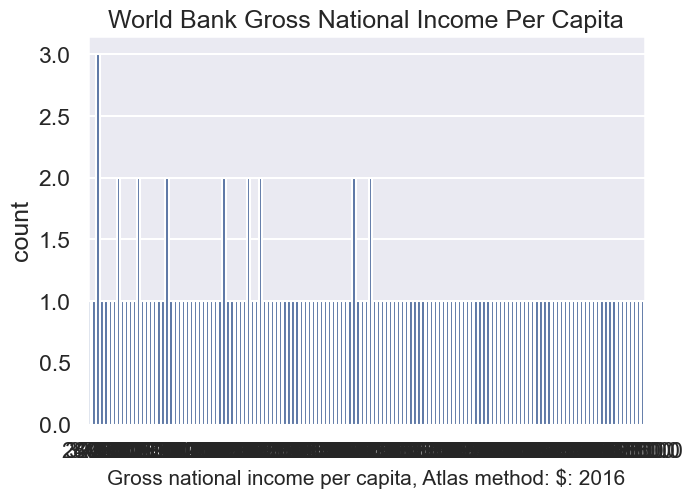

In [8]:
sns.countplot(data=df, x="inc")
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=15)
plt.title('World Bank Gross National Income Per Capita')
plt.show()

`countplot`不适合可视化这两列数据的原因：<br>
1. 标签太密集（因为识字率和人均收入中的每个值都被视为一类，类别很多）
2. 数值变化不大，有很多重复的数值
3. countplot用于分类数据，计算分类变量中每个唯一值的出现次数并绘制计数。

### Q1b 使用`histplot`创建人均收入图，包含标题和轴

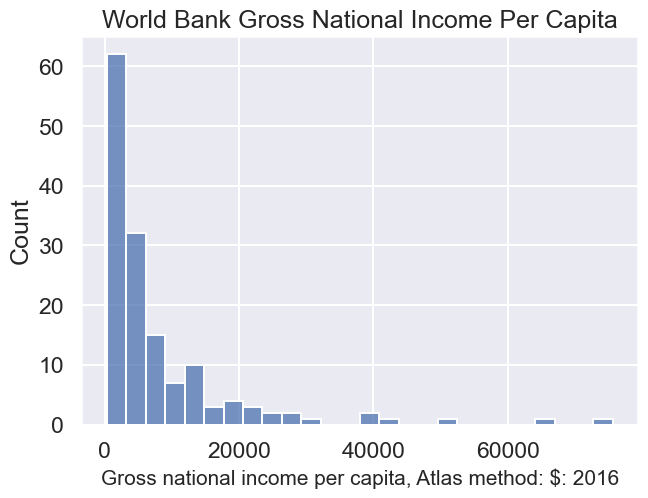

In [9]:
sns.histplot(data=df, x="inc")
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=15)
plt.ylabel('Count')
plt.title('World Bank Gross National Income Per Capita')
plt.show()

探索使用`rugplot`（地毯图）叠加在`displot`上

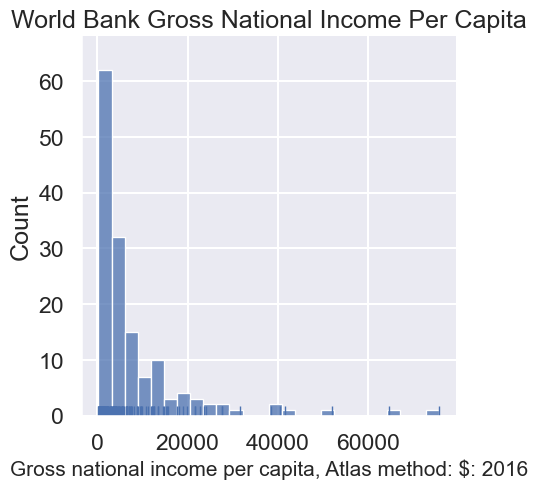

In [10]:
# Run this cell to overlay a rugplot on the displot; no further action is needed.
sns.displot(data=df, x="inc")
sns.rugplot(data=df, x="inc")
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=15)
plt.title('World Bank Gross National Income Per Capita')
plt.show()

将`rugplot`叠加在`histplot`上，并设置不同的颜色

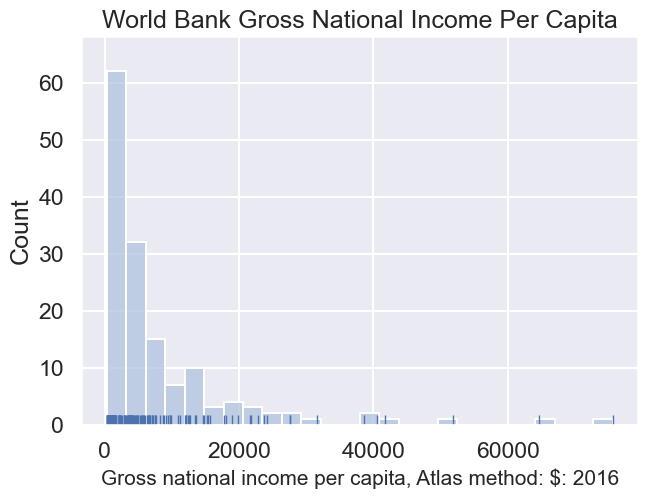

In [11]:
# Run this cell to overlay a rugplot on the histplot; no further action is needed.
sns.histplot(data=df, x="inc", color="lightsteelblue")
sns.rugplot(data=df, x="inc")
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=15)
plt.title('World Bank Gross National Income Per Capita')
plt.show()

**使用`displot`**同时绘制`histplot`, `rugplot`和 `kdeplot`

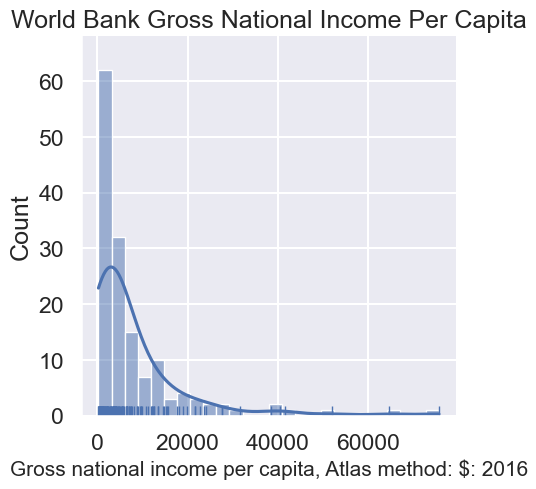

In [12]:
# Run this cell to generate a displot; no further action is needed.
sns.displot(data=df, x="inc", rug=True, kde=True)
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=15)
plt.title('World Bank Gross National Income Per Capita')
plt.show()

y轴用密度，使用识字率数据

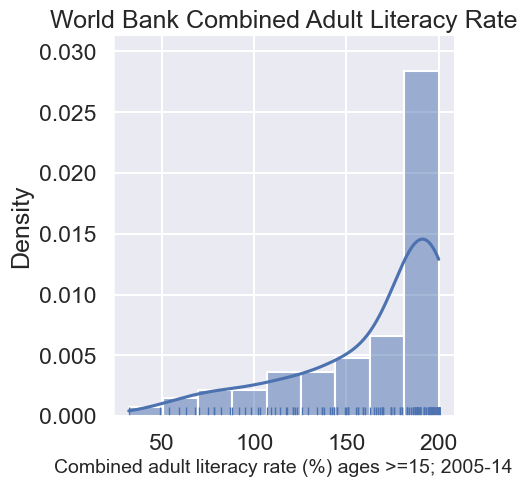

In [13]:
# Run this cell to generate a displot; no further action is needed.
sns.displot(data=df, x="lit", rug=True, kde=True, stat="density")
plt.xlabel("Combined adult literacy rate (%) ages >=15; 2005-14", fontsize=14)
plt.title('World Bank Combined Adult Literacy Rate')
plt.show()

### Q1c 由于人均收入数据在左侧过于密集，具有较长的右尾（右偏分布），使用`np.log10`对`inc`数据进行对数变换后再绘图

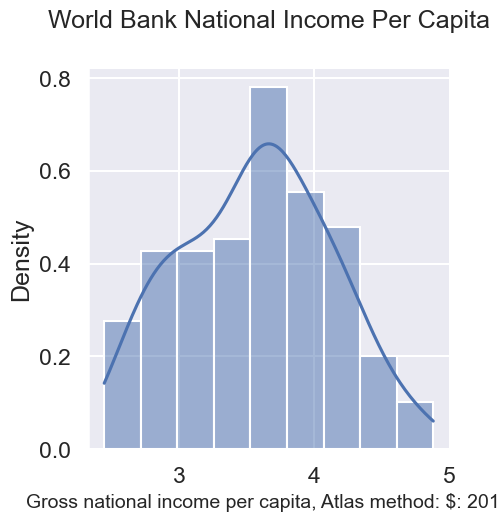

In [60]:
# Run this cell to generate the plot; no further action is needed.
ax = sns.displot(data=df, x=np.log10(df['inc']), kde=True, stat='density')
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=14)
plt.ylabel('Density')
plt.title('World Bank National Income Per Capita', pad=30)
plt.show()

识字率变量存在上限（百分数不能超过100%），分布会形成较长的左尾，通过**幂变换**来使其趋于对称

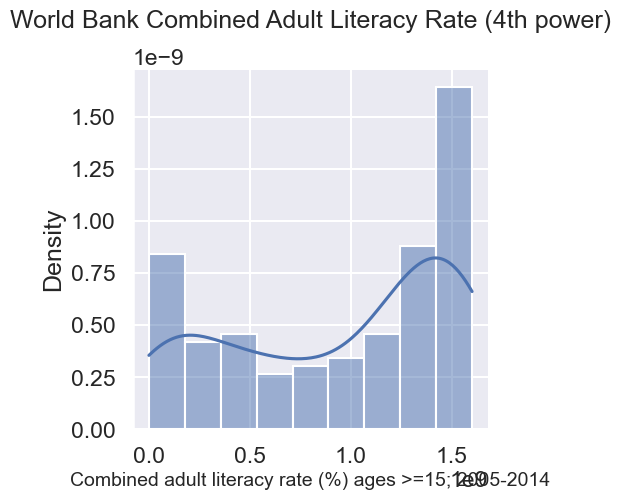

In [15]:
# Run this cell to generate the plot; no further action is needed.
ax = sns.displot(data=df, x=df['lit']**4, kde=True, stat='density')
plt.xlabel("Combined adult literacy rate (%) ages >=15; 2005-2014", fontsize=14)
plt.ylabel('Density')
plt.title('World Bank Combined Adult Literacy Rate (4th power)', pad=30)
plt.show()

### Q1d 检查识字率与人均国民收入间的关系，使用散点图`sns.sscatterplot`

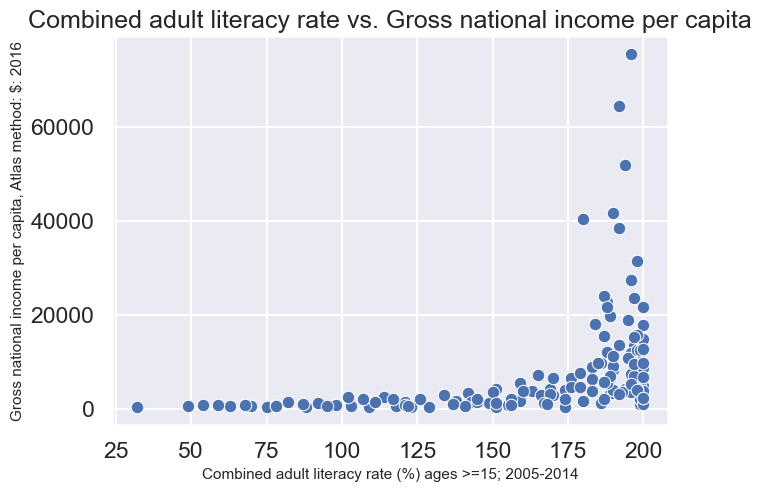

In [16]:
sns.scatterplot(data=df, x='lit', y='inc')
plt.xlabel('Combined adult literacy rate (%) ages >=15; 2005-2014', fontsize=11)
plt.ylabel('Gross national income per capita, Atlas method: $: 2016', fontsize=11)
plt.title('Combined adult literacy rate vs. Gross national income per capita')
plt.show()

查看对数转换后的收入和识字率的关系

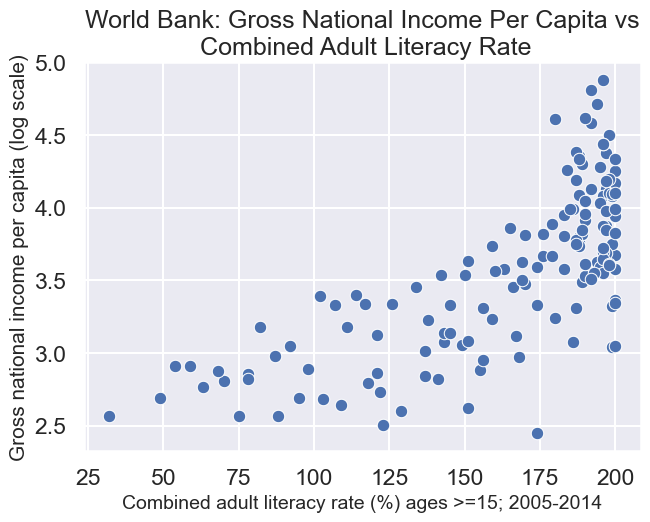

In [17]:
sns.scatterplot(data=df, x='lit', y=np.log10(df['inc']))
plt.xlabel("Combined adult literacy rate (%) ages >=15; 2005-2014", fontsize=14)
plt.ylabel('Gross national income per capita (log scale)', fontsize=15)
plt.title('World Bank: Gross National Income Per Capita vs\n Combined Adult Literacy Rate')
plt.show()

尝试用识字率的平方和人均收入的对数绘图

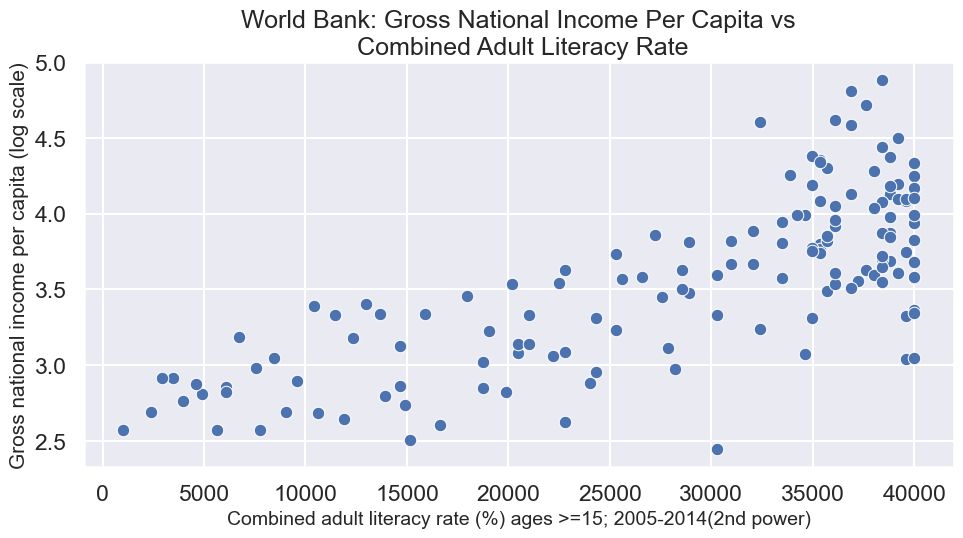

In [18]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x=df['lit'] ** 2, y = np.log10(df['inc']))
plt.xlabel("Combined adult literacy rate (%) ages >=15; 2005-2014(2nd power)", fontsize=14)
plt.ylabel('Gross national income per capita (log scale)', fontsize=15)
plt.title('World Bank: Gross National Income Per Capita vs\n Combined Adult Literacy Rate')
plt.show()

为关系选择最佳转换通常是在保持模型简单和拉直散点图之间取得平衡。

## Q2 核密度估计
### Q2a 
高斯内核：
$$\Large
K_\alpha(x, z) = \frac{1}{\sqrt{2 \pi \alpha^2}} \exp\left(-\frac{(x - z)^2}{2  \alpha ^2} \right)
$$
在下面用python实现了高斯核，`alpha`是KDE $\alpha$的平滑或贷款参数，`z`是高斯分布的中心（数据点或数据点数组），`x`是正在绘制其分布的变量的数组<br>
即`z`是平滑KDE曲线的中心点，x是要生成KDE图的值范围

In [19]:
def gaussian_kernel(alpha, x, z):
    """
    Compute the Gaussian density estimate for values in x.

    Args:
        alpha: the smoothing parameter to pass to the kernel.
        x: an array of values whose density will be calculated.
        z: center of Gaussian.

    Returns:
        The smoothed estimate at values of x.
    """    
    return 1.0/np.sqrt(2. * np.pi * alpha**2) * np.exp(-(x - z) ** 2 / (2.0 * alpha**2))

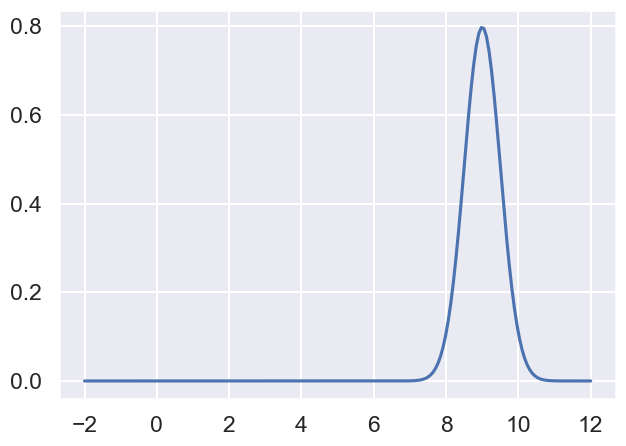

In [20]:
xs = np.linspace(-2, 12, 200)
alpha = 0.5
kde_curve = [gaussian_kernel(alpha, x, 9) for x in xs]
plt.plot(xs, kde_curve)
plt.show()

在同一个轴上绘制与三个数据点：`[2, 4, 9]`对于的三个核密度函数，使用0.5的`alpha`值

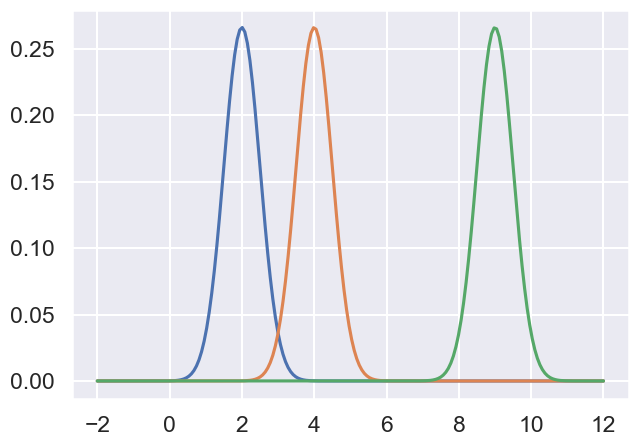

In [53]:
xs = np.linspace(-2, 12, 200)
data3pts = np.array([2, 4, 9])
alpha = 0.5
kde_curve3 = [1/3 * gaussian_kernel(alpha, x, data3pts)for x in xs]
plt.plot(xs, kde_curve3)
plt.show()

# xs = np.linspace(-2, 12, 200)
# alpha = 0.5
# data3pts = [2, 4, 9]
# n = len(data3pts) # 数据点的数量

# # 计算每个数据点的归一化高斯核曲线
# # 方法一：使用列表推导式
# kde_curves = [gaussian_kernel(alpha, xs, z) / n for z in data3pts]
# for curve in kde_curves:
#     plt.plot(xs, curve)
# plt.show()

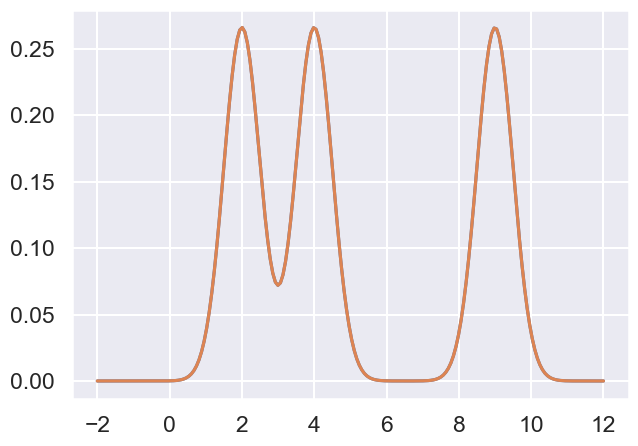

In [32]:
# Run this cell to plot the sum of the kernels; no further action is needed.
xs = np.linspace(-2, 12, 200)
alpha = 0.5
kde_curve = np.array([1/3 * gaussian_kernel(alpha, x, data3pts) for x in xs])
plt.plot(xs, np.sum(kde_curve, axis=1))
plt.show()

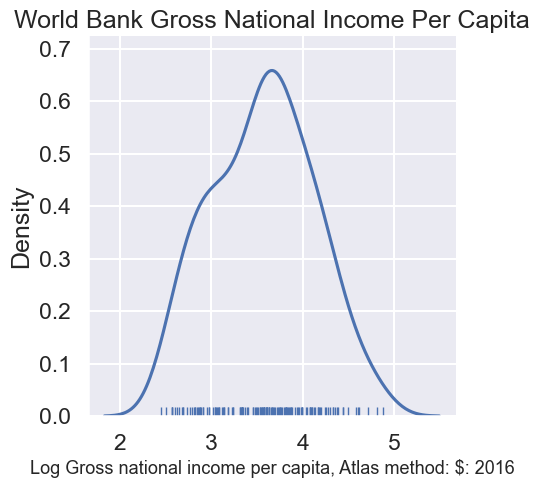

In [33]:
# Run this cell to plot KDE of log income; no further action is needed.
ax = sns.displot(data=df, x=np.log10(df['inc']), kind='kde', rug=True)
plt.xlabel('Log Gross national income per capita, Atlas method: $: 2016', fontsize=13)
plt.title('World Bank Gross National Income Per Capita')
plt.show()

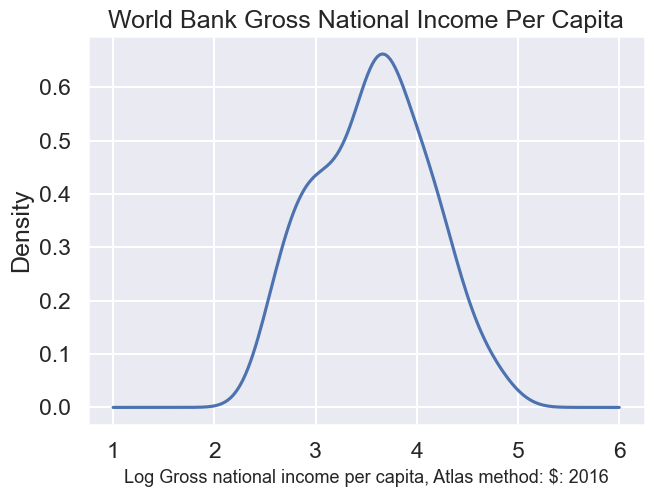

In [46]:
# Run this cell to plot KDE of log income; try out different bandwidths!
xs = np.linspace(1, 6, 200)
alpha = 0.2
kde_curve = np.array([1/len(df['inc']) * gaussian_kernel(alpha, x, np.log10(df['inc'])) for x in xs])
plt.xlabel('Log Gross national income per capita, Atlas method: $: 2016', fontsize=13)
plt.ylabel("Density")
plt.title('World Bank Gross National Income Per Capita')
plt.plot(xs, np.sum(kde_curve, axis = 1))
plt.show()

### Q2b 构建通用核密度估计函数
实现KDE函数
$$\Large
f_\alpha(x) = \frac{1}{n} \sum_{i=1}^n K_\alpha(x, z_i)
$$


In [43]:
def kde(kernel, alpha, x, data):
    """
    Compute the kernel density estimate for the single query point x.

    Args:
        kernel: a kernel function with 3 parameters: alpha, x, and data.
        alpha: the smoothing parameter to pass to the kernel.
        x: a single query point (in one dimension).
        data: a NumPy array of data points.

    Returns:
        The smoothed estimate at the query point x.
    """    
    n = len(data)
    kernel_values = np.sum(kernel(alpha, x, data)) /n
    return kernel_values
kde(gaussian_kernel, 1.0, 2.0, np.array([3.0, 4.0, 5.0, 7.0]))

0.07509875654094604

In [44]:
grader.check("q2b")

q2b results: All test cases passed!

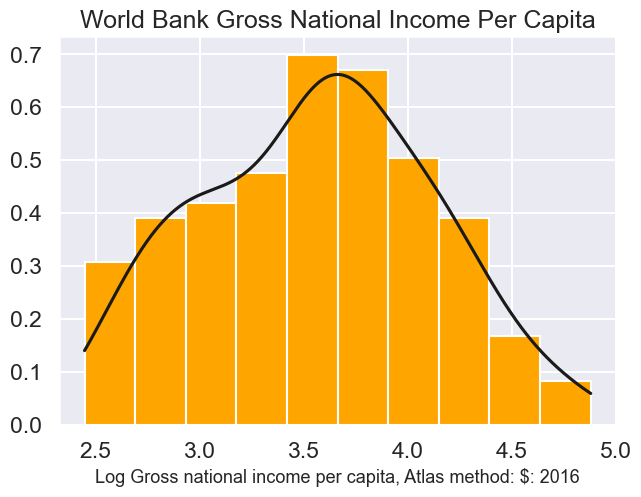

In [47]:
# Run this cell to generate the kde of the log of the income data; no further action is needed.
df['trans_inc'] = np.log10(df['inc'])
xs = np.linspace(df['trans_inc'].min(), df['trans_inc'].max(), 1000)
curve = [kde(gaussian_kernel, alpha, x, df['trans_inc']) for x in xs]
plt.hist(df['trans_inc'], density=True, color='orange')
plt.xlabel('Log Gross national income per capita, Atlas method: $: 2016', fontsize = 13);
plt.title('World Bank Gross National Income Per Capita')
plt.plot(xs, curve, 'k-')
plt.show()

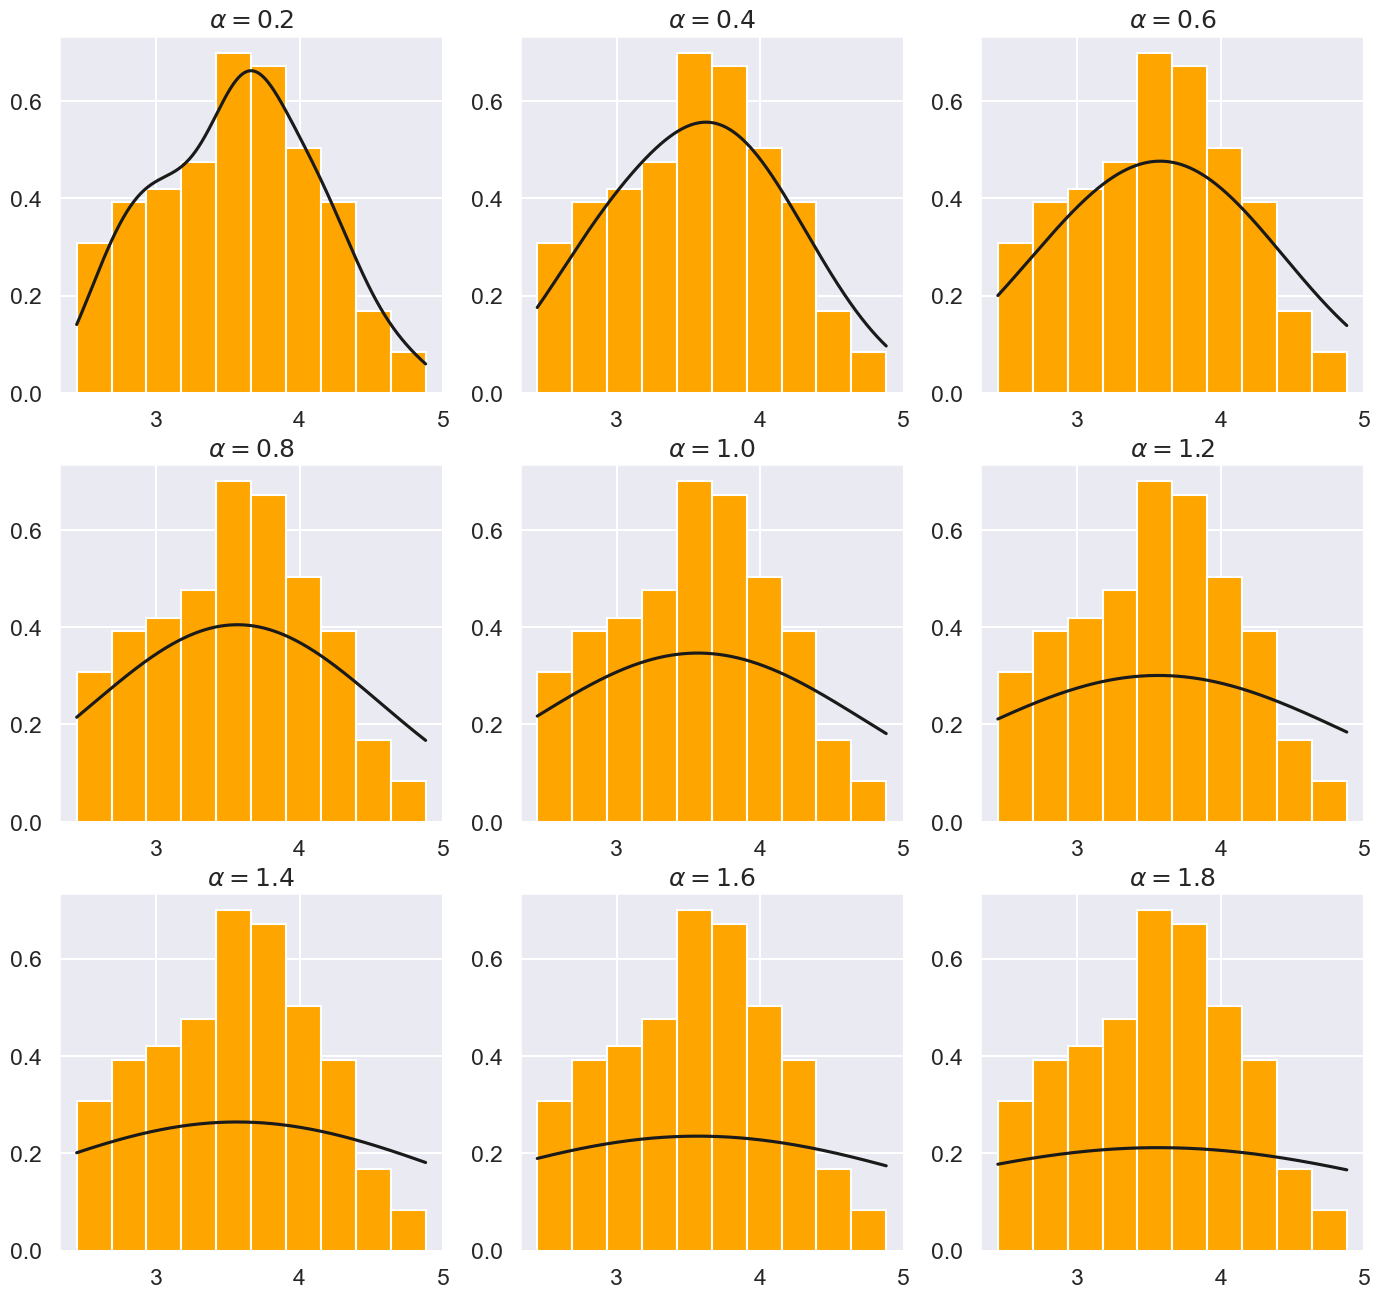

In [48]:
# Run this cell to generate the kde of the log of the income data 
# with different alphas values, no further action is needed.
plt.figure(figsize=(15,15))
alphas = np.arange(0.2, 2.0, 0.2)
for i, alpha in enumerate(alphas):
    plt.subplot(3, 3, i+1)
    xs = np.linspace(df['trans_inc'].min(), df['trans_inc'].max(), 1000)
    curve = [kde(gaussian_kernel, alpha, x, df['trans_inc']) for x in xs]
    plt.hist(df['trans_inc'], density=True, color='orange')
    plt.plot(xs, curve, 'k-')
    plt.title(r"$\alpha = " + format(alpha, ".02") + "$")
plt.show()

### Q2c Boxar核，定义：
\begin{equation} \Large
K_{a}(x, z) =
    \begin{cases}
        \frac{1}{\alpha}, & \text{if } -\frac{\alpha}{2} \leq (x-z) \leq \frac{\alpha}{2}\\
        0, & \text{otherwise}
    \end{cases}
\end{equation}

In [49]:
def boxcar_kernel(alpha, x, z):
    """
    Compute the boxcar density estimate for values in x.

    Args:
        alpha: the smoothing parameter to pass to the kernel.
        x: an array of values whose density will be calculated.
        z: center of boxcar function.

    Returns:
        The smoothed estimate at values of x.
    """    
    return (((x-z)>=-alpha/2)&((x-z)<=alpha/2))/alpha

交互式绘图

In [50]:
from ipywidgets import interact

In [51]:
x = np.linspace(-10,10,1000)
def f(alpha):
    plt.plot(x, boxcar_kernel(alpha,x,0), label='Boxcar')
    plt.plot(x, gaussian_kernel(alpha,x,0), label='Gaussian')
    plt.legend(title='Kernel Function')
    plt.show()
interact(f, alpha=(1,10,0.1));

interactive(children=(FloatSlider(value=5.0, description='alpha', max=10.0, min=1.0), Output()), _dom_classes=…

In [55]:
demo = 2 # ... # set this value to 1 or 2,1是data3pts，2是log的income

if demo == 1:
    xs = np.linspace(data3pts.min()-3, data3pts.max()+3, 1000)
    def f(alpha_g, alpha_b):
        plt.hist(data3pts, density=True, color='orange')
        g_curve = [kde(gaussian_kernel, alpha_g, x, data3pts) for x in xs]
        plt.plot(xs, g_curve, 'k-', label='Gaussian')
        b_curve = [kde(boxcar_kernel, alpha_b, x, data3pts) for x in xs]
        plt.plot(xs, b_curve, 'r-', label='Boxcar')
        plt.legend(title='Kernel Function')
        plt.show()
    interact(f, alpha_g=(0.01,.5,0.01), alpha_b=(0.01,3,0.1));
else:
    xs = np.linspace(df['trans_inc'].min(), df['trans_inc'].max(), 1000)
    def f(alpha_g, alpha_b):
        plt.hist(df['trans_inc'], density=True, color='orange')
        g_curve = [kde(gaussian_kernel, alpha_g, x, df['trans_inc']) for x in xs]
        plt.plot(xs, g_curve, 'k-', label='Gaussian')
        b_curve = [kde(boxcar_kernel, alpha_b, x, df['trans_inc']) for x in xs]
        plt.plot(xs, b_curve, 'r-', label='Boxcar')
        plt.legend(title='Kernel Function')
        plt.show()
    interact(f, alpha_g=(0.01,.5,0.01), alpha_b=(0.01,3,0.1));

interactive(children=(FloatSlider(value=0.25, description='alpha_g', max=0.5, min=0.01, step=0.01), FloatSlide…

alpha值相同时，高斯核更平滑，boxcar核呈锯齿状，局部起伏很大，稍微有点过拟合

## Q3 `sns.kdeplot`

### Q3a 用`sns.kdeplot`创建人均收入的KDE图

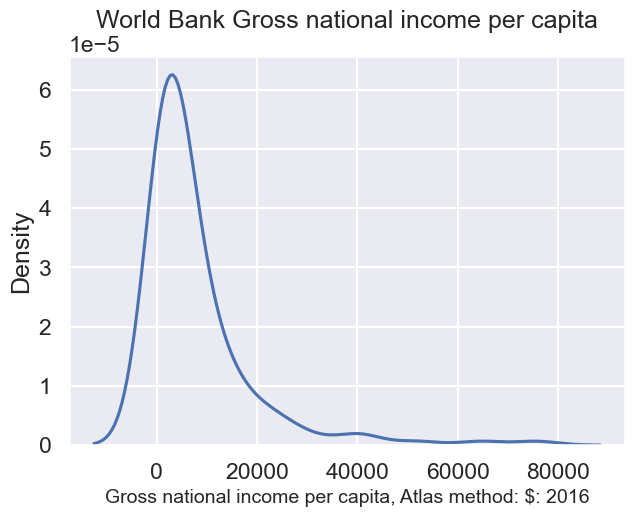

In [57]:
sns.kdeplot(data=df, x='inc')
plt.xlabel('Gross national income per capita, Atlas method: $: 2016', fontsize=14)
plt.title('World Bank Gross national income per capita')
plt.show()

可以看到曲线延伸到x轴的负值，对人均收入来说没有意义，发生这种情况是因为有很多数据点集中在 0 附近，导致图向右倾斜。对数转换图将为我们提供更对称的值分布，从而更容易看到模式。<br>
不要使用np.log10()，设置kdeplot参数log_scale=True

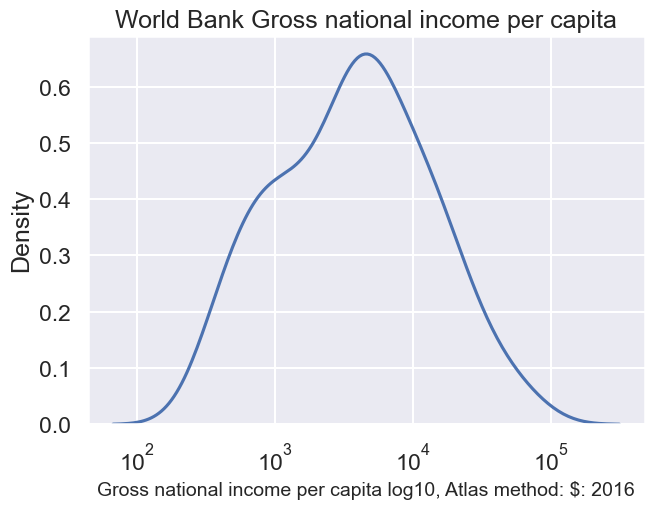

In [59]:
sns.kdeplot(data=df, x='inc', log_scale=True)
plt.xlabel('Gross national income per capita log10, Atlas method: $: 2016', fontsize=14)
plt.title('World Bank Gross national income per capita')
plt.show()

Q1c 的log应用在x轴的单位上，所以得到的x轴上的数据尺度是2-5+<br>
Q3b 是修改x轴的刻度为对数刻度